In [1]:
import os
from pathlib import Path
import pandas as pd

from vascx import preprocess, Retina
from vascx.features import Tortuosity, Caliber, Length
from vascx.features.tortuosity import TortuosityMeasure, Zone
from vascx.utils.analysis import get_examples_dict, make_retina
from vascx.analysis.vessel_resolve import RecursiveWeightedAverageResolver

In [2]:
def get_examples(data_path):
    meta = pd.read_csv(data_path + "/meta.csv", index_col="id")

    masks_path = os.path.join(data_path, "av")
    discs_path = os.path.join(data_path, "discs")
    fundus_path = os.path.join(data_path, "preprocessed_rgb")

    masks = sorted(list(Path(masks_path).glob("*.png")))
    discs = sorted(list(Path(discs_path).glob("*.png")))
    fundus = sorted(list(Path(fundus_path).glob("*.png")))

    ids_list = [int(m.stem.split("_")[0]) for m in masks]
    # ids = set(ids_list)
    discs = [d for d in discs if int(d.stem.split("_")[0]) in ids_list]
    fundus = [f for f in fundus if int(f.stem.split("_")[0]) in ids_list]
    scale_factors = [
        meta.loc[id, "scaling_w"] * meta.loc[id, "scale"] for id in ids_list
    ]

    assert len(discs) == len(masks), f"{len(discs)} != {len(masks)}"
    assert len(fundus) == len(masks), f"{len(fundus)} != {len(masks)}"
    assert len(scale_factors) == len(masks), f"{len(scale_factors)} != {len(masks)}"
    # assert len(logits) == len(masks)

    return {
        ex[0]: (ex[1], ex[2], ex[3], ex[4])
        for ex in zip(ids_list, scale_factors, masks, discs, fundus)
    }


In [3]:
ds_path = "../../samples/ergo/good/"

In [4]:
examples = get_examples_dict(ds_path)

In [5]:
examples.keys()

dict_keys([210281, 245938, 252853, 279724, 318392, 344501, 353780, 360268, 375802, 560772, 578298, 604547, 704166, 706168, 803630, 805765])

In [6]:
ret = make_retina(examples[360268])

In [7]:
tort = Tortuosity(TortuosityMeasure.Curvature, Zone.All)

<__array_function__ internals>:200: RuntimeWarning: invalid value encountered in cast


(<Figure size 1200x1200 with 1 Axes>, <Axes: >)

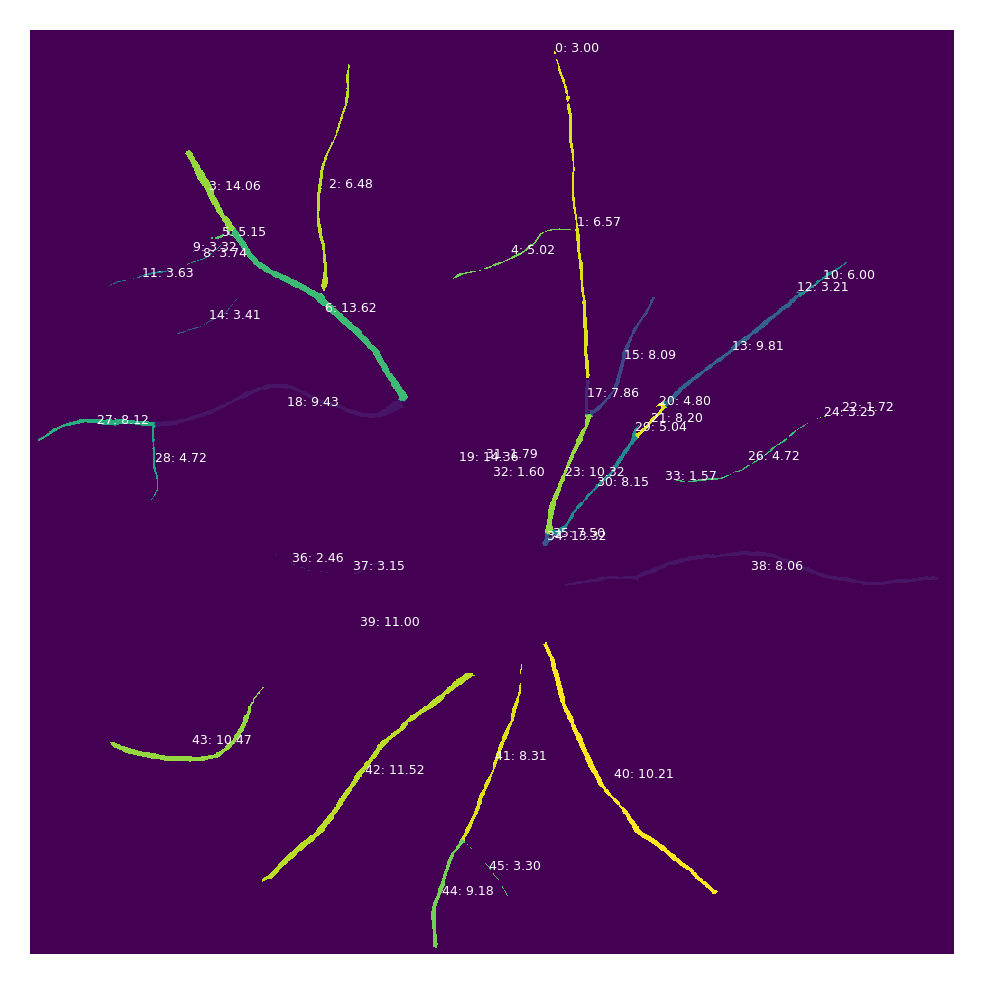

In [8]:
ret.arteries.plot_segments(text=lambda s: f'{s.median_diameter:.2f}')

(<Figure size 1200x1200 with 1 Axes>, <Axes: >)

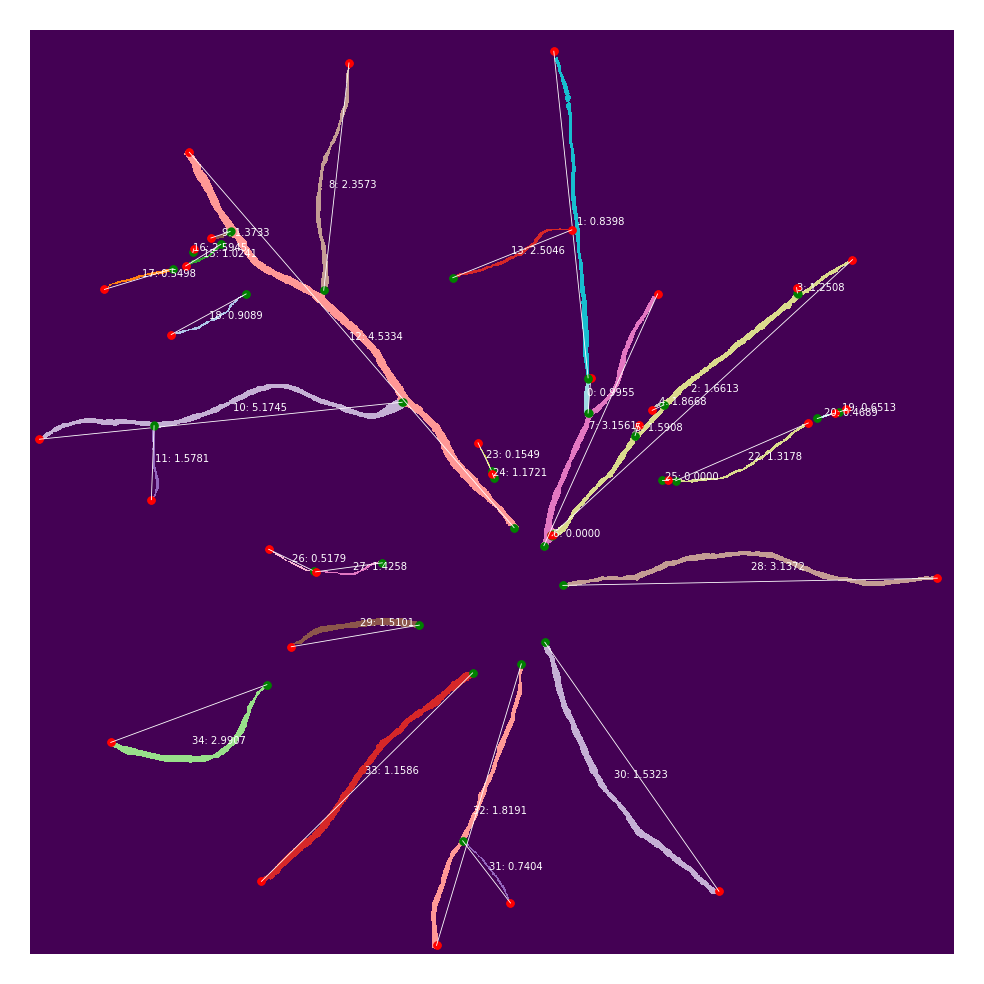

In [9]:
tort.plot(ret.arteries)

(<Figure size 1200x1200 with 1 Axes>, <Axes: >)

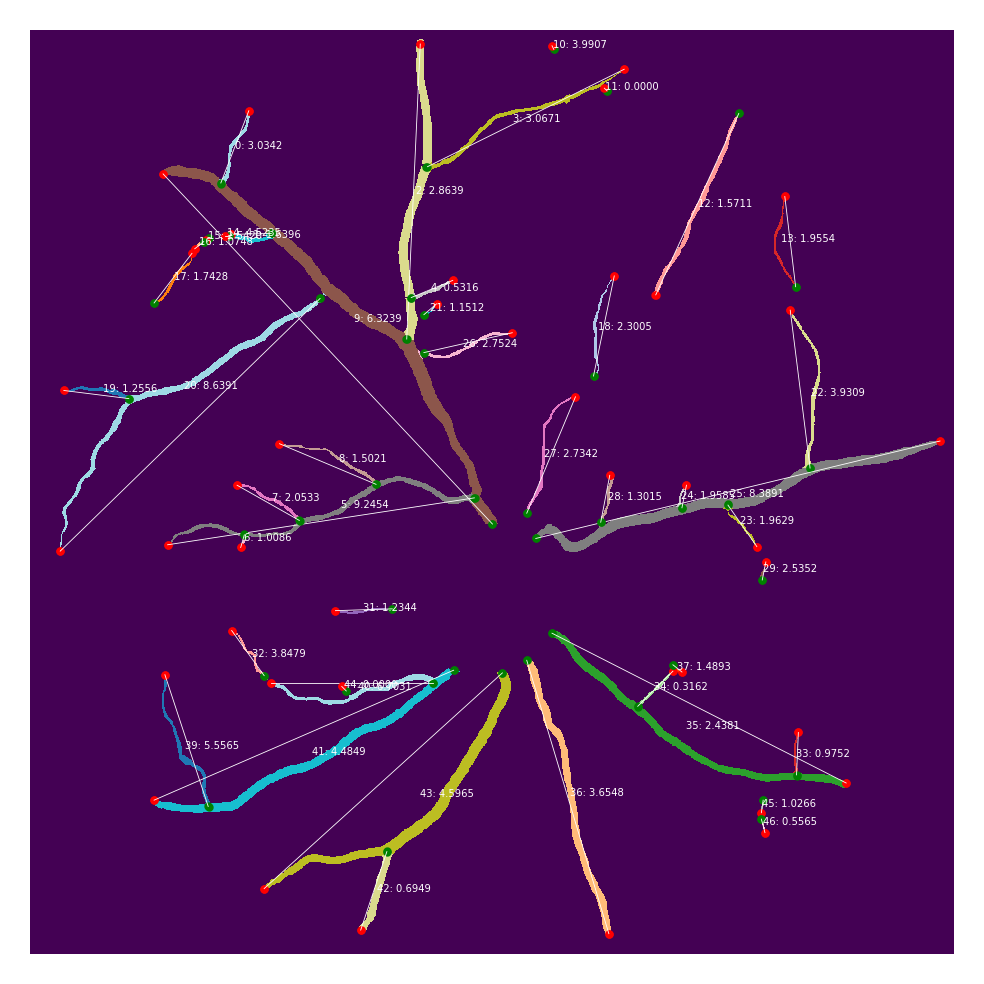

In [10]:
tort.plot(ret.veins)